<a href="https://colab.research.google.com/github/Johnal96/ITAI2373-NewsBot-Midterm/blob/main/itai2373_newsbot_midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
print("Please upload your kaggle.json file:")
uploaded = files.upload()

Please upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
!unzip /content/learn-ai-bbc.zip

Archive:  /content/learn-ai-bbc.zip
replace BBC News Sample Solution.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: BBC News Sample Solution.csv  
  inflating: BBC News Test.csv       
  inflating: BBC News Train.csv      


In [ ]:
df = pd.read_csv('/content/BBC News Train.csv')
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
print(df.head())

Dataset Info:
Shape: (1490, 3)
Columns: ['ArticleId', 'Text', 'Category']

First few rows:
   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business


In [ ]:
df = pd.read_csv('/content/BBC News Sample Solution.csv')
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
print(df.head())

Dataset Info:
Shape: (735, 2)
Columns: ['ArticleId', 'Category']

First few rows:
   ArticleId       Category
0       1018          sport
1       1319           tech
2       1138       business
3        459  entertainment
4       1020       politics


In [ ]:
df = pd.read_csv('/content/BBC News Test.csv')
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
print(df.head())

Dataset Info:
Shape: (735, 2)
Columns: ['ArticleId', 'Text']

First few rows:
   ArticleId                                               Text
0       1018  qpr keeper day heads for preston queens park r...
1       1319  software watching while you work software that...
2       1138  d arcy injury adds to ireland woe gordon d arc...
3        459  india s reliance family feud heats up the ongo...
4       1020  boro suffer morrison injury blow middlesbrough...


In [ ]:
text_column = 'Text'  # or 'description', 'content', 'headline', etc.
category_column = 'Category'  # or 'label', 'class', etc.

In [ ]:
print(f"\nMissing values:")
print(df.isnull().sum())


Missing values:
ArticleId    0
Text         0
dtype: int64


In [ ]:
df = pd.read_csv('/content/BBC News Train.csv')
df_clean = df.dropna(subset=[text_column, category_column])

In [ ]:
print(f"\nCategory distribution:")
print(df_clean[category_column].value_counts())


Category distribution:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


In [ ]:
if len(df_clean) > 2000:
    df_final = df_clean.sample(n=2000, random_state=42)
    print(f"\nSampled dataset to {len(df_final)} rows")
else:
    df_final = df_clean

In [ ]:
df_final = df_final.rename(columns={
    text_column: 'content',
    category_column: 'category'
})

In [ ]:
df_final.to_csv('newsbot_dataset.csv', index=False)
print("\n✅ Dataset prepared and saved as 'newsbot_dataset.csv'")


✅ Dataset prepared and saved as 'newsbot_dataset.csv'


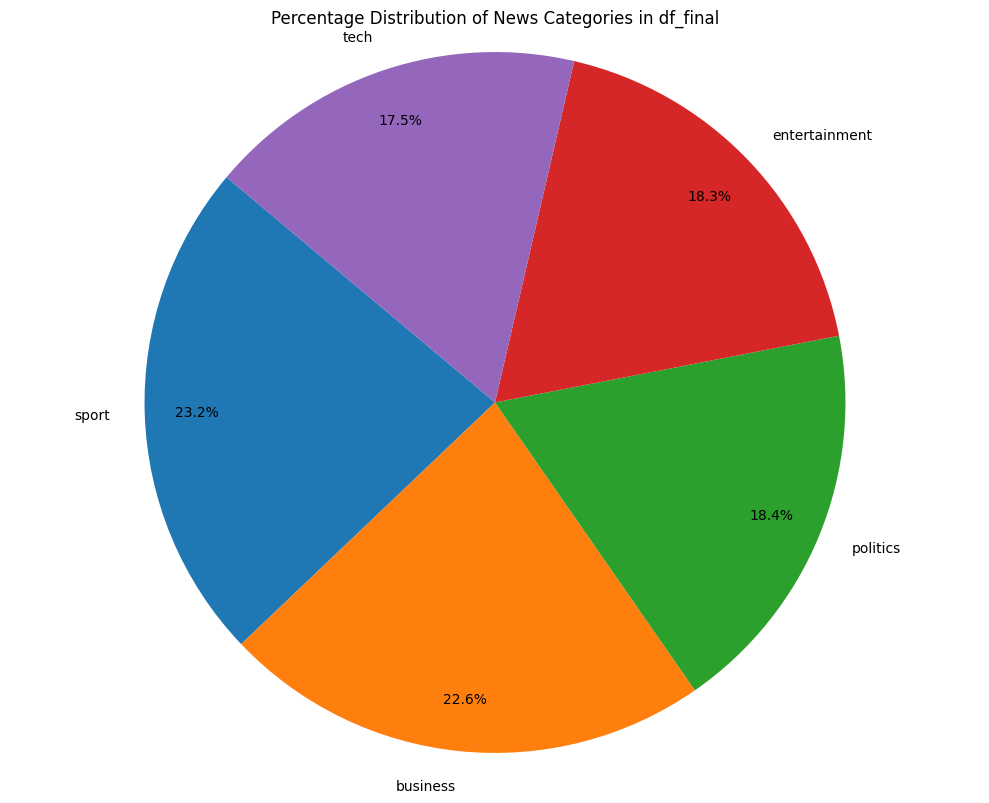

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

category_counts = df_final['category'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
plt.title('Percentage Distribution of News Categories in df_final')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()